In [1]:
from pathlib import Path

import pandas as pd

import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent

FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

In [4]:
results = pd.DataFrame({

    "Split":[
        "Spatial Block Split",
        "Random Stratified Split"
    ],

    "Accuracy":[
        0.7479,
        0.8872
    ],

    "Macro F1":[
        0.7451,
        0.8836
    ]

})

results

,Split,Accuracy,Macro F1
0,Spatial Block Split,0.7479,0.7451
1,Random Stratified Split,0.8872,0.8836


In [5]:
results.to_csv(

    FIGURE_DIR /
    "spatial_leakage_comparison.csv",

    index=False

)

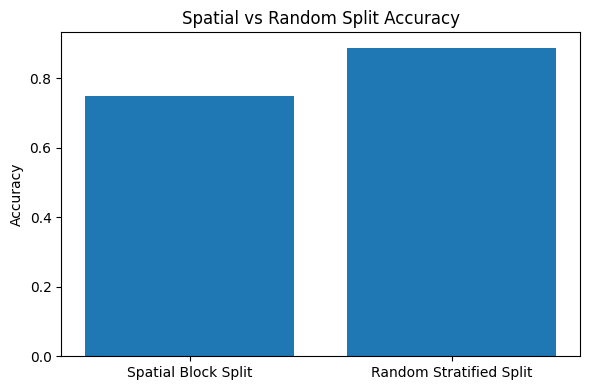

In [6]:
plt.figure(figsize=(6,4))

plt.bar(
    results["Split"],
    results["Accuracy"]
)

plt.ylabel("Accuracy")

plt.title("Spatial vs Random Split Accuracy")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "spatial_leakage_accuracy.png",
    dpi=300
)

plt.show()

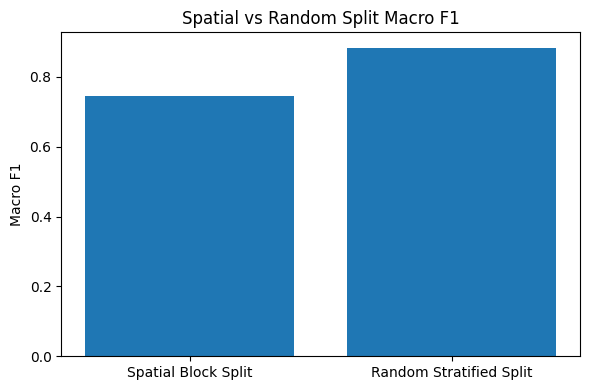

In [7]:
plt.figure(figsize=(6,4))

plt.bar(
    results["Split"],
    results["Macro F1"]
)

plt.ylabel("Macro F1")

plt.title("Spatial vs Random Split Macro F1")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "spatial_leakage_macro_f1.png",
    dpi=300
)

plt.show()

In [8]:
acc_diff = (
    results.loc[1, "Accuracy"]
    -
    results.loc[0, "Accuracy"]
)

f1_diff = (
    results.loc[1, "Macro F1"]
    -
    results.loc[0, "Macro F1"]
)

print(f"Accuracy Difference : {acc_diff:.4f}")

print(f"Macro F1 Difference : {f1_diff:.4f}")

Accuracy Difference : 0.1393
Macro F1 Difference : 0.1385


Spatial Leakage Analysis

The model trained using a random stratified split achieved higher performance than the model trained using a spatial block split. In the random split, images from nearby geographic regions may appear in both the training and test sets, making the evaluation easier because of spatial autocorrelation. The spatial block split prevents this by assigning entire geographic regions exclusively to one split, providing a more realistic estimate of performance on unseen locations. This experiment demonstrates that random image-level splitting can overestimate real-world generalization performance for satellite imagery.

Using a conventional random stratified split increased ResNet18 accuracy from 74.8% to 88.7% (+13.9%). This indicates that random image-level splitting substantially overestimates model performance due to spatial leakage. Holding out entire geographic regions provides a more realistic estimate of generalization to unseen locations.